## Table of Contents

- [Imports](#imports)
- [Set time range](#set-time-range)
- [Define Stock Tickers and Labels](#define-stock-tickers-and-labels)
- [Download Stock Data](#download-stock-data)
- [Focus on 'Close' Prices](#focus-on-close-prices)
- [Organize Data Chronologically](#organize-data-chronologically)
- [Count the Number of Stocks](#count-the-number-of-stocks)
- [List of Companies Analyzed](#list-of-companies-analyzed)
- [Check for Missing Data](#check-for-missing-data)
- [Dataset Overview](#dataset-overview)
- [Line Plot Function for Raw Prices](#line-plot-function-for-raw-prices)
- [Unnormalized Stock Prices (2015–2025)](#unnormalized-stock-prices-2015–2025)
- [Price Extremes](#price-extremes)
- [View Stock Prices on Specific Date](#view-stock-prices-on-specific-date)
- [Interactive Time Series Plot with Plotly](#interactive-time-series-plot-with-plotly)
- [Display Interactive Chart (Unnormalized)](#display-interactive-chart-unnormalized)
- [Normalize Function](#normalize-function)
- [Normalized Data Preview](#normalized-data-preview)
- [Removing Nvidia to Improve Visibility](#removing-nvidia-to-improve-visibility)
- [Normalized Stock Performance (2015–2025)](#normalized-stock-performance-2015–2025)
- [NVIDIAs Outlier Performance: 2015–2025](#nvidias-outlier-performance-2015–2025)
- [Daily Return Function](#daily-return-function)
- [Daily Return DataFrame](#daily-return-dataframe)
- [Daily Returns Correlation Matrix](#daily-returns-correlation-matrix)
- [Correlation Heatmap](#correlation-heatmap)
- [Histogram of Daily Returns](#histogram-of-daily-returns)
- [Preparing Daily Returns for Distribution Plot](#preparing-daily-returns-for-distribution-plot)
- [Interactive Distribution Plot (Plotly Figure Factory)](#interactive-distribution-plot-plotly-figure-factory)


## Imports

This section imports the necessary Python libraries for data manipulation, visualization, and financial data retrieval.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.figure_factory as ff
import yfinance as yf
import datetime as dt

pio.templates.default = "plotly_white"


## 📅 Set Date Range
We define the time period for analysis, covering January 1, 2015 to the present date.

In [36]:
# Set time range

end = dt.datetime.now()
start = dt.datetime(2015, 1, 1)
start, end

(datetime.datetime(2015, 1, 1, 0, 0),
 datetime.datetime(2025, 8, 2, 18, 46, 45, 18669))

## 🏷️ Define Stock Tickers and Labels
This block creates a list of stock tickers for 10 large-cap companies across various sectors, plus the S&P 500 index. We also create a mapping to convert ticker symbols to company names for readability.

In [37]:
# Define the list of stock tickers
tickers = ['JNJ', 'PG', 'KO', 'MSFT', 'BRK-B', 'V', 'TSLA', 'NVDA', 'META', 'AMZN','^GSPC']

# Define a mapping from tickers to full names
ticker_name_map = {
    'JNJ': 'Johnson & Johnson',
    'PG': 'Procter & Gamble',
    'KO': 'Coca-Cola',
    'MSFT': 'Microsoft',
    'BRK-B': 'Berkshire Hathaway',
    'V': 'Visa',
    'TSLA': 'Tesla',
    'NVDA': 'Nvidia',
    'META': 'Meta Platforms',
    'AMZN': 'Amazon',
    '^GSPC': 'S&P 500'
}



## 📥 Download Stock Data
We fetch historical stock data using Yahoo Finance via yfinance.download(). The data includes daily price metrics such as Open, High, Low, Close, Volume, etc.



In [38]:
tickers = ['JNJ', 'PG', 'KO', 'MSFT', 'BRK-B', 'V', 'TSLA', 'NVDA', 'META', 'AMZN','^GSPC']
df = yf.download(tickers, start=start, end=end)
df.rename(columns=ticker_name_map, inplace=True)
df

/tmp/ipython-input-3202654242.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  11 of 11 completed


Price            Close                                                  \
Ticker          Amazon Berkshire Hathaway Johnson & Johnson  Coca-Cola   
Date                                                                     
2015-01-02   15.426000         149.169998         78.012596  30.222628   
2015-01-05   15.109500         147.000000         77.467751  30.222628   
2015-01-06   14.764500         146.839996         77.087097  30.452122   
2015-01-07   14.921000         148.880005         78.788857  30.832226   
2015-01-08   15.023000         151.369995         79.408379  31.205166   
...                ...                ...               ...        ...   
2025-07-28  232.789993         481.700012        166.220001  68.089996   
2025-07-29  231.009995         476.559998        168.110001  69.379997   
2025-07-30  230.190002         476.000000        167.259995  68.750000   
2025-07-31  234.110001         471.880005        164.740005  67.889999   
2025-08-01  214.750000         472.839996        167.330002  68.860001   

Price                                                               \
Ticker     Meta Platforms   Microsoft      Nvidia Procter & Gamble   
Date                                                                 
2015-01-02      78.021957   39.998699    0.483066        66.983490   
2015-01-05      76.768845   39.630875    0.474907        66.665016   
2015-01-06      75.734520   39.049202    0.460508        66.361343   
2015-01-07      75.734520   39.545341    0.459308        66.709473   
2015-01-08      77.753441   40.708683    0.476586        67.472328   
...                   ...         ...         ...              ...   
2025-07-28     717.630005  512.500000  176.750000       157.110001   
2025-07-29     700.000000  512.570007  175.509995       156.610001   
2025-07-30     695.210022  513.239990  179.270004       152.880005   
2025-07-31     773.440002  533.500000  177.869995       150.470001   
2025-08-01     750.010010  524.109985  173.720001       150.649994   

Price                               ...             Volume                    \
Ticker           Tesla        Visa  ... Berkshire Hathaway Johnson & Johnson   
Date                                ...                                        
2015-01-02   14.620667   61.570610  ...            3436400           5753600   
2015-01-05   14.006000   60.211521  ...            4168800           8079300   
2015-01-06   14.085333   59.823540  ...            4116100           7428000   
2015-01-07   14.063333   60.625069  ...            4159100           7931700   
2015-01-08   14.041333   61.438206  ...            4282100           9916000   
...                ...         ...  ...                ...               ...   
2025-07-28  325.589996  355.470001  ...            3626100           8014600   
2025-07-29  321.200012  351.290009  ...            4193200           7663400   
2025-07-30  319.040009  350.910004  ...            3803000           6189200   
2025-07-31  308.269989  345.470001  ...            6315300          11036200   
2025-08-01  302.630005  339.350006  ...            5283000           8927800   

Price                                                                      \
Ticker     Coca-Cola Meta Platforms Microsoft     Nvidia Procter & Gamble   
Date                                                                        
2015-01-02   9921100       18177500  27913900  113680000          7251400   
2015-01-05  26292600       26452200  39673900  197952000          8626100   
2015-01-06  16897500       27399300  36447900  197764000          7791200   
2015-01-07  13412300       22045300  29114100  321808000          5986600   
2015-01-08  21743600       23961000  29645200  283780000          6823300   
...              ...            ...       ...        ...              ...   
2025-07-28  13668800        8715700  14308000  140023500          7885000   
2025-07-29  16223400       13267000  16469200  154077500         11466100   
2025-07-30  10

## 🎯 Focus on 'Close' Prices
We isolate the 'Close' prices, which represent the final trading price of each day — a standard metric for stock performance analysis.

In [39]:
close = df['Close']
close

Ticker,Amazon,Berkshire Hathaway,Johnson & Johnson,Coca-Cola,Meta Platforms,Microsoft,Nvidia,Procter & Gamble,Tesla,Visa,S&P 500
Date,,,,,,,,,,,
2015-01-02,15.426000,149.169998,78.012596,30.222628,78.021957,39.998699,0.483066,66.983490,14.620667,61.570610,2058.199951
2015-01-05,15.109500,147.000000,77.467751,30.222628,76.768845,39.630875,0.474907,66.665016,14.006000,60.211521,2020.579956
2015-01-06,14.764500,146.839996,77.087097,30.452122,75.734520,39.049202,0.460508,66.361343,14.085333,59.823540,2002.609985
2015-01-07,14.921000,148.880005,78.788857,30.832226,75.734520,39.545341,0.459308,66.709473,14.063333,60.625069,2025.900024
2015-01-08,15.023000,151.369995,79.408379,31.205166,77.753441,40.708683,0.476586,67.472328,14.041333,61.438206,2062.139893
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-28,232.789993,481.700012,166.220001,68.089996,717.630005,512.500000,176.750000,157.110001,325.589996,355.470001,6389.770020
2025-07-29,231.009995,476.559998,168.110001,69.379997,700.000000,512.570007,175.509995,156.610001,321.200012,351.290009,6370.859863
2025-07-30,230.190002,476.000000,167.259995,68.750000,695.210022,513.239990,179.270004,152.880005,319.040009,350.910004,6362.899902


## 📊 Organize Data Chronologically
Ensure the DataFrame is sorted by date to maintain consistent time-series formatting.

In [40]:
# Sort the stock data by date
close = close.sort_index()

close


Ticker,Amazon,Berkshire Hathaway,Johnson & Johnson,Coca-Cola,Meta Platforms,Microsoft,Nvidia,Procter & Gamble,Tesla,Visa,S&P 500
Date,,,,,,,,,,,
2015-01-02,15.426000,149.169998,78.012596,30.222628,78.021957,39.998699,0.483066,66.983490,14.620667,61.570610,2058.199951
2015-01-05,15.109500,147.000000,77.467751,30.222628,76.768845,39.630875,0.474907,66.665016,14.006000,60.211521,2020.579956
2015-01-06,14.764500,146.839996,77.087097,30.452122,75.734520,39.049202,0.460508,66.361343,14.085333,59.823540,2002.609985
2015-01-07,14.921000,148.880005,78.788857,30.832226,75.734520,39.545341,0.459308,66.709473,14.063333,60.625069,2025.900024
2015-01-08,15.023000,151.369995,79.408379,31.205166,77.753441,40.708683,0.476586,67.472328,14.041333,61.438206,2062.139893
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-28,232.789993,481.700012,166.220001,68.089996,717.630005,512.500000,176.750000,157.110001,325.589996,355.470001,6389.770020
2025-07-29,231.009995,476.559998,168.110001,69.379997,700.000000,512.570007,175.509995,156.610001,321.200012,351.290009,6370.859863
2025-07-30,230.190002,476.000000,167.259995,68.750000,695.210022,513.239990,179.270004,152.880005,319.040009,350.910004,6362.899902


## 🔢 Count the Number of Stocks
Quickly confirm the total number of stocks included in the analysis.

In [41]:
# Print out the number of stocks
print('Total Number of stocks : {}'.format(len(close.columns)))

Total Number of stocks : 11


## 🧾 List of Companies Analyzed
Display the full names of the companies in our dataset.

In [42]:
# Print the name of stocks
print('Stocks under consideration are:')

for i in close.columns:
  print(i)

Stocks under consideration are:
Amazon
Berkshire Hathaway
Johnson & Johnson
Coca-Cola
Meta Platforms
Microsoft
Nvidia
Procter & Gamble
Tesla
Visa
S&P 500


## 🧹 Check for Missing Data
Detect and quantify any missing entries to ensure data integrity before analysis.

In [43]:
# Check if data contains any null values
close.isnull().sum()

,0
Ticker,
Amazon,0
Berkshire Hathaway,0
Johnson & Johnson,0
Coca-Cola,0
Meta Platforms,0
Microsoft,0
Nvidia,0
Procter & Gamble,0
Tesla,0


##📊 Dataset Overview
This section checks the structure and metadata of the close DataFrame. It includes the number of entries, data types, and memory usage, helping us understand the shape of the dataset before analysis.

In [44]:
# Getting dataframe info
close.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2661 entries, 2015-01-02 to 2025-08-01
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Amazon              2661 non-null   float64
 1   Berkshire Hathaway  2661 non-null   float64
 2   Johnson & Johnson   2661 non-null   float64
 3   Coca-Cola           2661 non-null   float64
 4   Meta Platforms      2661 non-null   float64
 5   Microsoft           2661 non-null   float64
 6   Nvidia              2661 non-null   float64
 7   Procter & Gamble    2661 non-null   float64
 8   Tesla               2661 non-null   float64
 9   Visa                2661 non-null   float64
 10  S&P 500             2661 non-null   float64
dtypes: float64(11)
memory usage: 249.5 KB


##📈 Line Plot Function for Raw Prices
This function creates a line plot for stock prices using Matplotlib. It's useful for visualizing long-term price movement trends across all included assets.



In [45]:
# Define a function to plot the entire dataframe
# The function performs data visualization
# Pandas works great with matplotlib, I'll simply plot data directly from a Pandas DataFrame using plot() method

def show_plot(df, fig_title):
    """
    Plots the stock data from a dataframe using Matplotlib.

    Args:
        df (pd.DataFrame): Data to plot
        fig_title (str): Title of the plot
    """
    df.plot(figsize=(15, 7), linewidth=1.5, title=fig_title)
    plt.grid()
    plt.show()


## 📈 Unnormalized Stock Prices (2015–2025)

This chart visualizes the unadjusted stock prices of **10 major companies** across various sectors — including tech, consumer goods, and healthcare — compared against the **S&P 500 index** over the last 10 years.

> 🟠 This is an unnormalized view, reflecting actual market price levels without adjusting for comparability or indexing.

### 🧭 Objective
To observe how raw price movements differ across leading companies and how they compare to the broader market index over a long-term horizon.



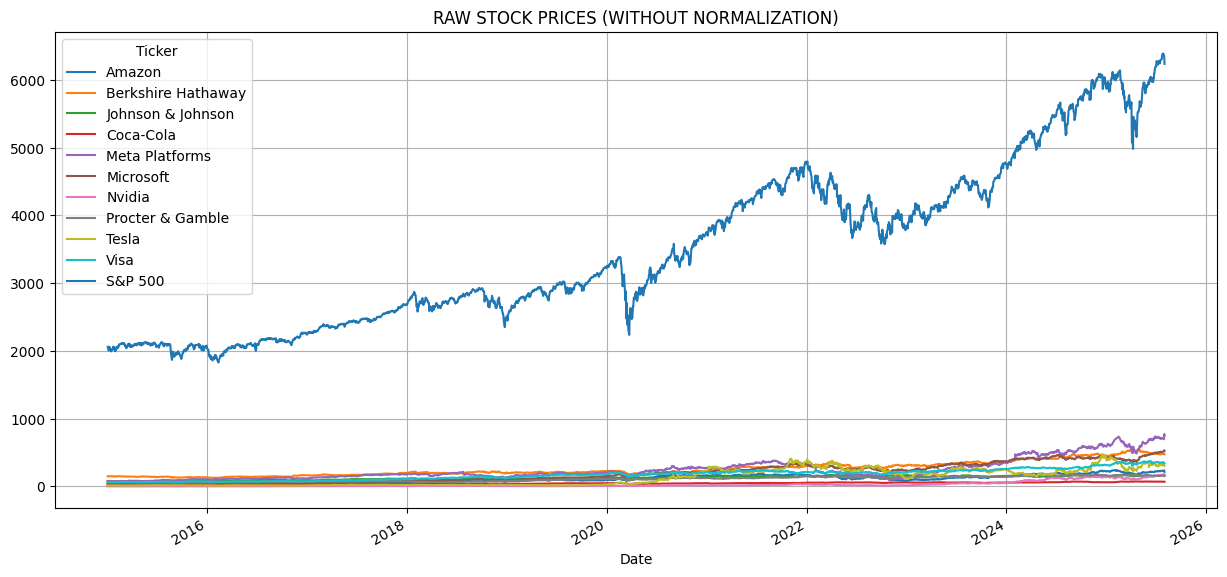

In [46]:
# Plot the data
show_plot(close, 'RAW STOCK PRICES (WITHOUT NORMALIZATION)')

## 🔽 Price Extremes
Here we calculate and display the minimum and maximum closing prices for each stock throughout the selected time period (2015–2025). This provides context on volatility and price range.

In [47]:
# Get the min and max values for each stock in the 'Close' DataFrame
min_close = close.min()
max_close = close.max()

# Print the min and max values
print("Minimum Closing Price for Each Stock:")
print(min_close)

print("\nMaximum Closing Price for Each Stock:")
max_close

Minimum Closing Price for Each Stock:
Ticker
Amazon                  14.347500
Berkshire Hathaway     124.129997
Johnson & Johnson       69.216728
Coca-Cola               27.698984
Meta Platforms          73.645988
Microsoft               34.558323
Nvidia                   0.459308
Procter & Gamble        51.593876
Tesla                    9.578000
Visa                    57.235443
S&P 500               1829.079956
dtype: float64

Maximum Closing Price for Each Stock:


,0
Ticker,
Amazon,242.059998
Berkshire Hathaway,539.799988
Johnson & Johnson,169.559998
Coca-Cola,73.378281
Meta Platforms,773.440002
Microsoft,533.500000
Nvidia,179.270004
Procter & Gamble,176.298782
Tesla,479.859985


## 📅 View Stock Prices on Specific Date
This function allows users to query the stock prices on a particular date, useful for snapshot analysis or event-based research.

In [48]:
def view_stock_prices_on_date(close, date_to_view):
    """
    Prints the stock prices from a given DataFrame for a specific date.

    Args:
        close (pd.DataFrame): DataFrame containing stock prices, with dates as index.
        date_to_view (str): The date to retrieve prices for (format: 'YYYY-MM-DD').

    Returns:
        None: Prints the stock prices or a message if the date is not found.
    """
    if date_to_view in close.index:
        print(close.loc[date_to_view])
    else:
        print(f"Data for {date_to_view} not found in the DataFrame.")

view_stock_prices_on_date(close, '2020-08-11')


Ticker
Amazon                 154.033493
Berkshire Hathaway     212.660004
Johnson & Johnson      127.520256
Coca-Cola               41.185650
Meta Platforms         254.732529
Microsoft              194.855469
Nvidia                  10.814354
Procter & Gamble       117.731651
Tesla                   91.625999
Visa                   190.864487
S&P 500               3333.689941
Name: 2020-08-11 00:00:00, dtype: float64


## 🔄 Interactive Time Series Plot with Plotly
We define an interactive_plot() function to plot each asset using Plotly Express for an interactive, zoomable chart experience. This is excellent for web displays and presentations.

In [49]:


def interactive_plot(df, title):
    """
    Creates an interactive line plot using Plotly Express for multiple time series.

    Args:
        df (pd.DataFrame): A DataFrame where each column represents a stock or asset,
                           and the index represents time (e.g., dates).
        title (str): Title for the plot.

    Returns:
        plotly.graph_objects.Figure: A Plotly figure object with interactive features.
    """
    fig = px.line()  # We will add each trace manually below

    for column in df.columns:
        fig.add_scatter(x=df.index, y=df[column], name=column)

    fig.update_layout(title=title, xaxis_title='Date', yaxis_title='Value',
                      template='plotly_dark', height=500)

    return fig


## ▶️ Display Interactive Chart (Unnormalized)
This section uses the interactive_plot() function to visualize raw price movement across the full date range, before normalization.



In [67]:
fig = interactive_plot(close, 'STOCK PRICES (WITHOUT NORMALIZATION)')
fig.show()


![Unnormalized Stock Prices](stock_price_without_normalization.png)

> This is a static image version of the interactive Plotly chart.  
> If you're viewing this notebook on a platform that doesn't support Plotly (like GitHub), the image above lets you preview the data visually.  
>  
> 🔗 **[Click here to explore the full interactive chart](https://alex-adedoyin.github.io/python-stock-visualization/stock_price_without_normalization.html)**  
>  
> 📁 *If the image doesn’t display, you can [view it directly](https://alex-adedoyin.github.io/python-stock-visualization/stock_price_without_normalization.png).*


## 📐 Normalize Function
This function converts raw prices into indexed values starting at 1.0. It helps compare relative performance, especially when stock prices differ widely in scale.

In [52]:
def normalize(df):
    """
    Normalizes a DataFrame of time series data so that all columns start at 1.

    Each column is divided by its first value (row index 0), making it easy to
    compare percentage-based performance over time.

    Args:
        df (pd.DataFrame): A DataFrame of asset prices with datetime index and
                           one column per asset/ticker.

    Returns:
        pd.DataFrame: Normalized DataFrame where each column starts at 1.
    """
    normalized_df = df.copy()
    for column in normalized_df.columns:
        normalized_df[column] = normalized_df[column] / normalized_df[column].iloc[0]

    return normalized_df


## 📊 Normalized Data Preview
After normalization, all stocks begin at a common base. This preview confirms the transformation before plotting.

In [53]:
normalized_close = normalize(close)
normalized_close

Ticker,Amazon,Berkshire Hathaway,Johnson & Johnson,Coca-Cola,Meta Platforms,Microsoft,Nvidia,Procter & Gamble,Tesla,Visa,S&P 500
Date,,,,,,,,,,,
2015-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2015-01-05,0.979483,0.985453,0.993016,1.000000,0.983939,0.990804,0.983110,0.995245,0.957959,0.977926,0.981722
2015-01-06,0.957118,0.984380,0.988137,1.007593,0.970682,0.976262,0.953304,0.990712,0.963385,0.971625,0.972991
2015-01-07,0.967263,0.998056,1.009950,1.020170,0.970682,0.988666,0.950820,0.995909,0.961880,0.984643,0.984307
2015-01-08,0.973875,1.014748,1.017892,1.032510,0.996558,1.017750,0.986587,1.007298,0.960376,0.997850,1.001914
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-28,15.090756,3.229202,2.130682,2.252948,9.197795,12.812917,365.892330,2.345503,22.269161,5.773371,3.104543
2025-07-29,14.975366,3.194744,2.154908,2.295631,8.971833,12.814667,363.325380,2.338039,21.968902,5.705482,3.095355
2025-07-30,14.922210,3.190990,2.144013,2.274786,8.910441,12.831417,371.109022,2.282354,21.821166,5.699310,3.091488


## ❌ Removing Nvidia to Improve Visibility
Because of Nvidia’s extremely high growth, including it in the normalized chart visually flattens other stocks. This section removes Nvidia from the plot so we can better observe the performance patterns of the remaining assets.

In [54]:
# Exclude NVIDIA to better visualize the relative performance of other stocks
# Since NVIDIA's explosive growth flattens the appearance of the others

# Drop the 7th column (NVIDIA) by index — use column name for clarity
nvidia_column = normalized_close.columns[6]  # Assuming it's still in position 6
cleaned_df = normalized_close.drop(columns=[nvidia_column])

# Generate interactive Plotly chart
fig = interactive_plot(cleaned_df, 'Stock Prices Excluding NVIDIA (Normalized to 1)')


## 📈 Normalized Stock Performance (2015–2025)

This visualization compares the **relative price performance** of 9 major companies and the **S&P 500 Index**, normalized to a common starting point (indexed to 1) in 2015.

### 🎯 Purpose:
To reveal how each stock performed **in percentage terms** over a decade, enabling apples-to-apples comparison across different sectors and price levels.

### 📊 Key Observations:
- **Top Performers**:
  - **Tesla** showed the strongest growth, significantly outperforming the rest.
  - **Amazon** and **Microsoft** followed with steady and substantial long-term gains.
  
- **Moderate to Lower Growth**:
  - **Johnson & Johnson**, **Coca-Cola**, and **Procter & Gamble** showed stable but slower growth — consistent with their defensive, dividend-focused profiles.
  - The **S&P 500 Index** itself landed around the middle, outperforming some individual stocks while being outpaced by top growth names.

### ⚠️ Why NVIDIA Was Excluded:
NVIDIA's extraordinary performance in this period made other stocks appear visually flat in a normalized plot, reducing comparative clarity. It is analyzed separately for better contrast.


In [55]:
fig.update_layout(
    width=1000,
    height=500,
    template='plotly_dark',
    title='Normalized Stock Prices (Excluding Nvidia) vs S&P 500 (2015–2025)',
    title_font_size=22,
    title_x=0.5,  # center the title
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white')
)

fig.show()


![Normalized Stock Prices (Excl Nvidia)](Normalized_Stock_Prices_Excl_Nvidia.png)

> This is a static image version of the interactive Plotly chart.  
> If you're viewing this notebook on a platform that doesn't support Plotly (like GitHub), the image above lets you preview the data visually.  
>  
> 🔗 **[Click here to explore the full interactive chart](https://alex-adedoyin.github.io/python-stock-visualization/Normalized_Stock_Prices_Excl_Nvidia.html)**  
>  
> 📁 *If the image doesn’t display, you can [view it directly](https://alex-adedoyin.github.io/python-stock-visualization/Normalized_Stock_Prices_Excl_Nvidia.png).*


## 💥 NVIDIA's Outlier Performance: 2015–2025

In 2015, NVIDIA closed the year at **$0.8240**.  

By 2025, its price had risen to **$172.41**, representing a **total return of over 20,800%** across a single decade.

### 📊 Context:
This chart includes the same set of diversified stocks from earlier analysis — now with **NVIDIA** reintroduced into the normalized comparison.

Once included, **NVIDIA’s exceptional growth** compresses the visual scale of all other stocks. Strong performers like **Tesla**, **Amazon**, and **Microsoft** appear almost flat by comparison.

### 🔍 Key Takeaway:
NVIDIA exemplifies the impact of a statistical outlier in long-term investment performance:
- It drastically reshapes visual and analytical interpretations.
- It reinforces the importance of **growth investing**, innovation exposure, and portfolio tail events.

### 🧪 Method:
All stocks, including the **S&P 500 Index**, are normalized (indexed to 1) from a 2015 start date to allow for relative comparison of returns.


In [69]:
# Here, Nvidia is plotted along with others, one can now see it's incredible growth

fig = interactive_plot(normalized_close, 'STOCK PRICES (NORMALIZED i.e., Indexed to 1)')
fig.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white') # Also changing font color to white for better visibility on a black background
)
fig.write_html('normalized_stock_prices.html')
fig.show()

![Normalized Stock Prices (Incl Nvidia)](Stock_Prices_Normalized_incl_Nvidia.png)

> This is a static image version of the interactive Plotly chart.  
> If you're viewing this notebook on a platform that doesn't support Plotly (like GitHub), the image above lets you preview the data visually.  
>  
> 🔗 **[Click here to explore the full interactive chart](https://alex-adedoyin.github.io/python-stock-visualization/Stock_Prices_Normalized_incl_Nvidia.html)**  
>  
> 📁 *If the image doesn’t display, you can [view it directly](https://alex-adedoyin.github.io/python-stock-visualization/Stock_Prices_Normalized_incl_Nvidia.png).*


## 📉 Daily Return Function
This function calculates daily percentage changes for each stock using the common return formula. It's essential for correlation analysis, volatility assessment, and short-term analysis.



In [58]:
def daily_return(df):
    """
    Calculates daily percentage returns for each asset in the DataFrame.

    Uses the formula:
        return = [(Current Price - Previous Price) / Previous Price] * 100

    Args:
        df (pd.DataFrame): DataFrame of asset prices with datetime index.

    Returns:
        pd.DataFrame: DataFrame of daily returns (in %), with first row as 0.
    """
    df_daily_return = df.pct_change() * 100  # Vectorized computation
    df_daily_return.iloc[0] = 0  # First row has no prior value, so set to 0
    return df_daily_return


## 📊 Daily Return DataFrame
We generate a new DataFrame with daily return values for each stock. This will later be used to compute correlations or run simulations like CAPM or risk metrics.

In [59]:
# Get the daily returns
stocks_daily_return = daily_return(close)

In [60]:
stocks_daily_return

Ticker,Amazon,Berkshire Hathaway,Johnson & Johnson,Coca-Cola,Meta Platforms,Microsoft,Nvidia,Procter & Gamble,Tesla,Visa,S&P 500
Date,,,,,,,,,,,
2015-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-01-05,-2.051729,-1.454715,-0.698407,0.000000,-1.606103,-0.919591,-1.689019,-0.475451,-4.204103,-2.207366,-1.827811
2015-01-06,-2.283333,-0.108846,-0.491370,0.759345,-1.347323,-1.467726,-3.031838,-0.455520,0.566424,-0.644364,-0.889347
2015-01-07,1.059974,1.389273,2.207580,1.248202,0.000000,1.270550,-0.260541,0.524596,-0.156193,1.339822,1.162984
2015-01-08,0.683602,1.672481,0.786307,1.209579,2.665787,2.941792,3.761734,1.143549,-0.156431,1.341255,1.788828
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-28,0.583301,-0.489598,-1.235889,-1.561373,0.694563,-0.235546,1.873199,-0.751739,3.015250,-0.439729,0.017686
2025-07-29,-0.764637,-1.067057,1.137047,1.894553,-2.456698,0.013660,-0.701559,-0.318248,-1.348317,-1.175906,-0.295944
2025-07-30,-0.354960,-0.117508,-0.505625,-0.908039,-0.684283,0.130711,2.142334,-2.381710,-0.672479,-0.108174,-0.124943


##📊 Daily Returns Correlation Matrix
We compute the Pearson correlation matrix for the daily returns of all stocks. This reveals how closely the returns of different assets move together, helping with diversification analysis.

In [61]:
def calculate_correlation_matrix(df):
    """
    Calculates the correlation matrix of daily returns for a given DataFrame.

    Args:
        df (pd.DataFrame): A DataFrame of daily returns (percent), with each column
                           representing an asset and the index representing dates.

    Returns:
        pd.DataFrame: Correlation matrix showing pairwise correlation coefficients.
    """
    return df.corr()


## 🔥 Correlation Heatmap
This heatmap visualizes the correlation matrix using Seaborn, highlighting positive, negative, and neutral relationships between stocks. High correlation may suggest redundancy in diversification, while low or negative values indicate risk-spreading potential.

In [62]:
def plot_correlation_heatmap(corr_matrix, title='Daily Return Correlation', figsize=(10, 10)):
    """
    Plots a heatmap of a correlation matrix using Seaborn and Matplotlib.

    Args:
        corr_matrix (pd.DataFrame): A square DataFrame representing the correlation matrix.
        title (str): Title of the heatmap.
        figsize (tuple): Figure size in inches (width, height).

    Returns:
        None: Displays the heatmap plot.
    """
    plt.figure(figsize=figsize)
    ax = plt.subplot()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)
    ax.set_xlabel('Stocks')
    ax.set_ylabel('Stocks')
    plt.title(title)
    plt.savefig("daily_return_correlation.png")
    plt.show()


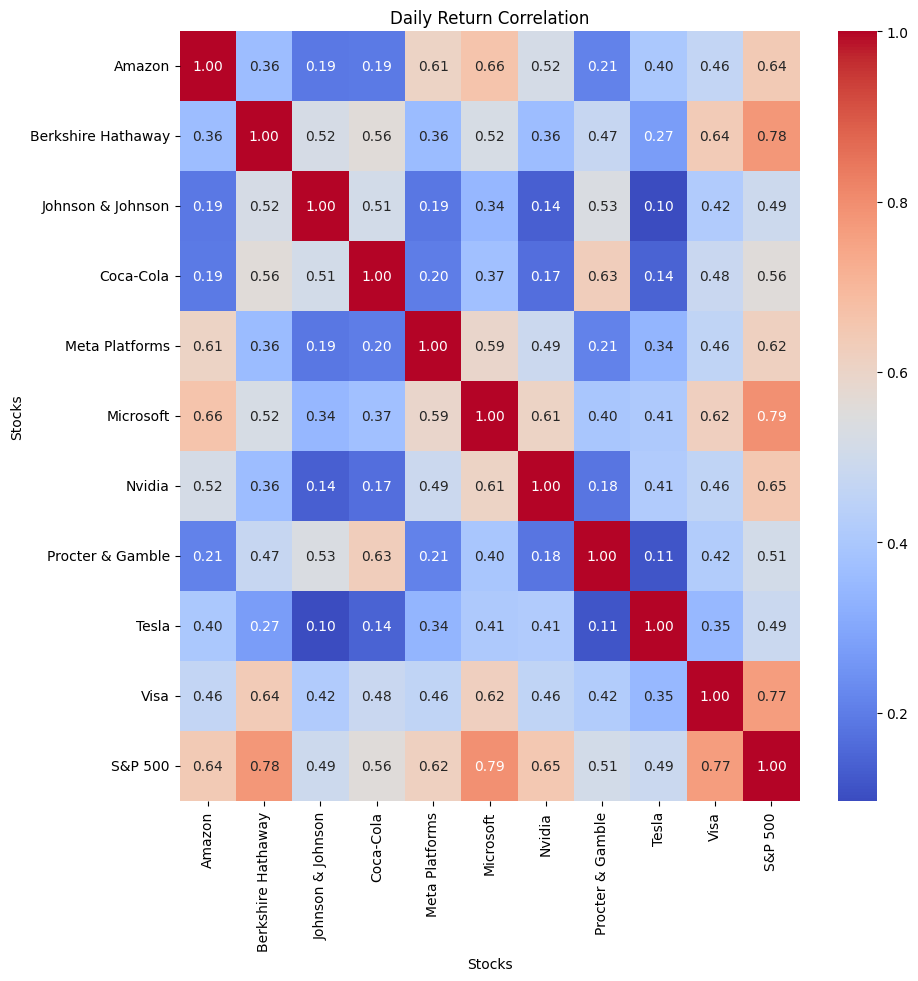

In [63]:
correlation_matrix = calculate_correlation_matrix(stocks_daily_return)
plot_correlation_heatmap(correlation_matrix)


##📊 Histogram of Daily Returns
This section displays histograms of daily returns for each stock in the portfolio.
You’ll notice that most distributions are centered around zero, consistent with how stock returns behave over time.

⚠️ Tesla, Nvidia, and Meta show larger standard deviations, reflecting higher volatility.



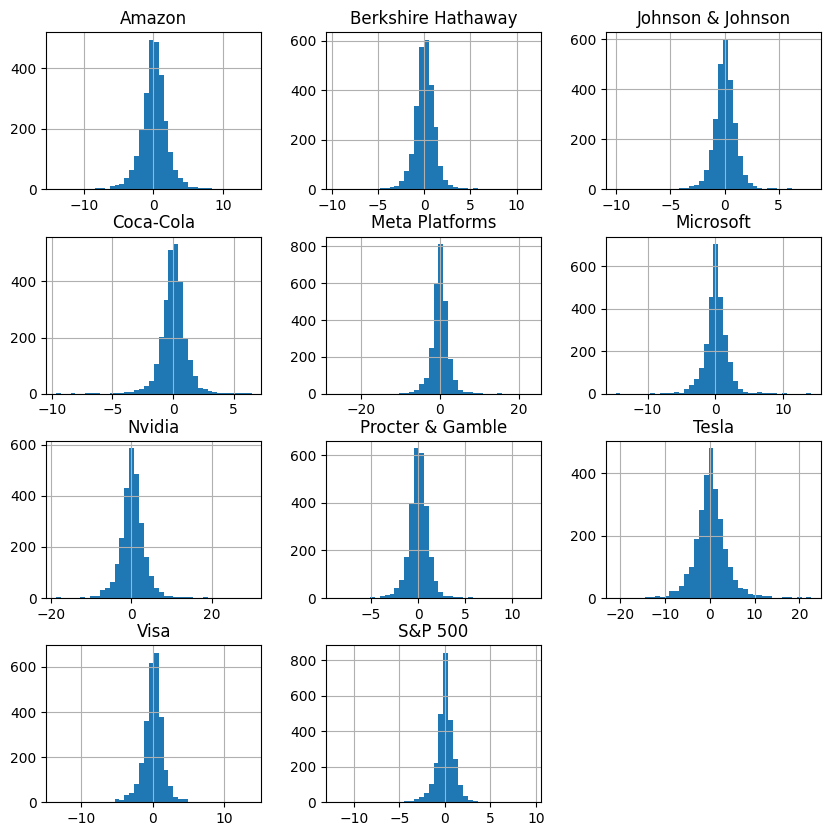

In [64]:
# Histogram of daily returns
# Stock returns are normally distributed with zero mean
# Notice how Tesla, Nvidia and Meta Platforms Standard deviation are high indicating a more volatile stock
stocks_daily_return.hist(figsize=(10, 10), bins = 40);

## 🗃️ Preparing Daily Returns for Distribution Plot
We group the daily returns of all stocks into a list, preparing them for a combined distribution visualization using Plotly’s Figure Factory. This allows us to compare return distributions side by side.

In [65]:
# Group all data returns together in a list
# Make a copy of the daily returns dataframe
df_hist = stocks_daily_return.copy()


data = []

# Loop through every column
for i in df_hist.columns:
  data.append(stocks_daily_return[i].values)
data

[array([ 0.        , -2.05172901, -2.28333346, ..., -0.35495956,
         1.70294024, -8.26961709]),
 array([ 0.        , -1.45471489, -0.10884603, ..., -0.1175083 ,
        -0.86554519,  0.20343974]),
 array([ 0.        , -0.69840719, -0.49137012, ..., -0.50562495,
        -1.50662986,  1.57217206]),
 array([ 0.        ,  0.        ,  0.75934527, ..., -0.90803874,
        -1.25090998,  1.42878366]),
 array([ 0.        , -1.60610274, -1.34732345, ..., -0.68428258,
        11.25271184, -3.02932259]),
 array([ 0.        , -0.91959129, -1.46772604, ...,  0.13071052,
         3.94747295, -1.76007772]),
 array([ 0.        , -1.68901928, -3.03183784, ...,  2.1423337 ,
        -0.78095003, -2.3331613 ]),
 array([ 0.        , -0.47545121, -0.45552046, ..., -2.3817098 ,
        -1.57640214,  0.11962031]),
 array([ 0.        , -4.20410282,  0.56642373, ..., -0.67247932,
        -3.37575829, -1.82955991]),
 array([ 0.        , -2.2073663 , -0.64436408, ..., -0.10817412,
        -1.55025573, -1.77

## 📈 Interactive Distribution Plot (Plotly Figure Factory)
Using Plotly’s figure_factory module, we generate an interactive chart showing the distribution of returns across all assets.
This offers a clean comparison of volatility, shape, and spread — key indicators of risk and consistency across stocks.

In [71]:
# Plotly's Python API contains a super powerful module known as figure factory module
# Figure factory module includes wrapper functions that create unique chart types such as interactive subplots

fig = ff.create_distplot(data, df_hist.columns)
fig.show()

![Distribution Plot of Daily Returns](Interactive_Distribution_Plot.png)

> This is a static image version of the interactive Plotly chart.  
> If you're viewing this notebook on a platform that doesn't support Plotly (like GitHub), the image above lets you preview the data visually.  
>  
> 🔗 **[Click here to explore the full interactive chart](https://alex-adedoyin.github.io/python-stock-visualization/Interactive_Distribution_Plot.html)**  
>  
> 📁 *If the image doesn’t display, you can [view it directly](https://alex-adedoyin.github.io/python-stock-visualization/Interactive_Distribution_Plot.png).*
